# 🎬 Movie Recommendation System — Exploratory Data Analysis
**Dataset:** MovieLens Latest Small | **Models:** TF-IDF · SVD · ALS · NCF · Hybrid

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
COLORS = ['#7c3aed','#3b82f6','#10b981','#f59e0b','#ef4444','#8b5cf6','#06b6d4','#84cc16']

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load Data
import os
os.chdir('..')  # go to project root

ratings = pd.read_csv('data/processed/ratings.csv')
movies  = pd.read_csv('data/processed/movies.csv')

print(f'✅ Ratings : {ratings.shape[0]:,} rows × {ratings.shape[1]} cols')
print(f'✅ Movies  : {movies.shape[0]:,} rows × {movies.shape[1]} cols')
print(f'\n📊 Ratings sample:')
display(ratings.head())
print(f'\n🎬 Movies sample:')
display(movies.head())

✅ Ratings : 100,836 rows × 4 cols
✅ Movies  : 9,742 rows × 3 cols

📊 Ratings sample:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



🎬 Movies sample:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 📊 1. Dataset Overview

In [3]:
print('='*50)
print('  DATASET SUMMARY')
print('='*50)
print(f'  Total Ratings   : {len(ratings):,}')
print(f'  Total Movies    : {len(movies):,}')
print(f'  Total Users     : {ratings["userId"].nunique():,}')
print(f'  Rating Scale    : {ratings["rating"].min()} to {ratings["rating"].max()}')
print(f'  Avg Rating      : {ratings["rating"].mean():.2f}')
print(f'  Total Genres    : {len(set("|".join(movies["genres"].dropna()).split("|"))):,}')
sparsity = 1 - (len(ratings) / (ratings["userId"].nunique() * movies["movieId"].nunique()))
print(f'  Matrix Sparsity : {sparsity*100:.2f}%')
print('='*50)

  DATASET SUMMARY
  Total Ratings   : 100,836
  Total Movies    : 9,742
  Total Users     : 610
  Rating Scale    : 0.5 to 5.0
  Avg Rating      : 3.50
  Total Genres    : 20
  Matrix Sparsity : 98.30%


## 📈 2. Rating Distribution

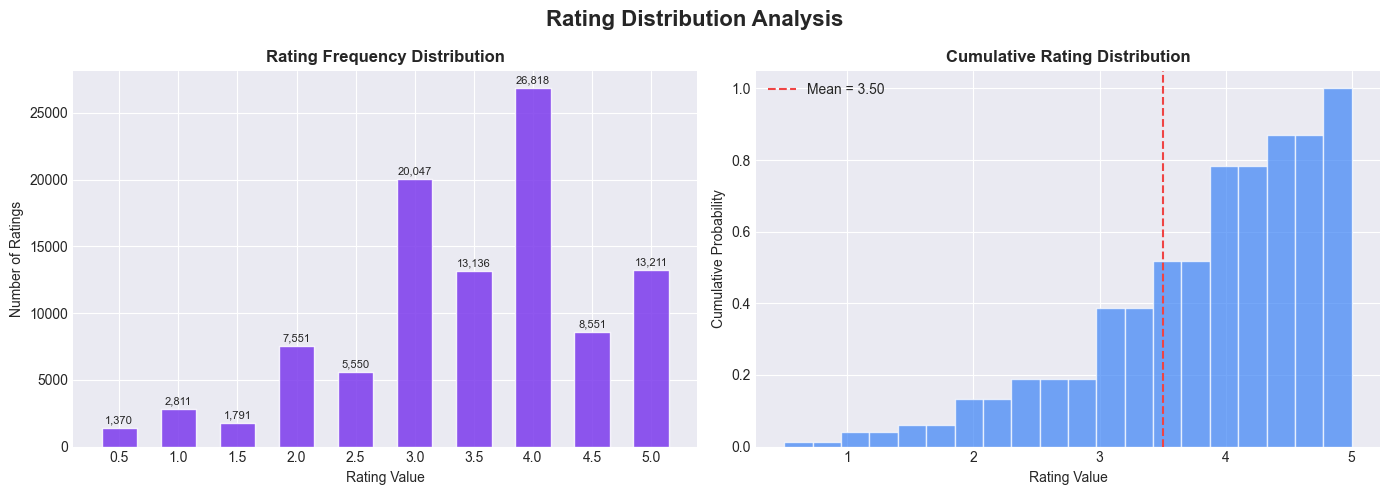

✅ Fig 1 saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Distribution Analysis', fontsize=16, fontweight='bold')

# Rating frequency
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color=COLORS[0], alpha=0.85, width=0.3, edgecolor='white')
axes[0].set_title('Rating Frequency Distribution', fontweight='bold')
axes[0].set_xlabel('Rating Value')
axes[0].set_ylabel('Number of Ratings')
axes[0].set_xticks([0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0])
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

# Cumulative distribution
axes[1].hist(ratings['rating'], bins=20, cumulative=True, density=True,
             color=COLORS[1], alpha=0.7, edgecolor='white')
axes[1].set_title('Cumulative Rating Distribution', fontweight='bold')
axes[1].set_xlabel('Rating Value')
axes[1].set_ylabel('Cumulative Probability')
axes[1].axvline(ratings['rating'].mean(), color=COLORS[4], linestyle='--',
                label=f'Mean = {ratings["rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/fig1_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 1 saved')

## 🎭 3. Genre Analysis

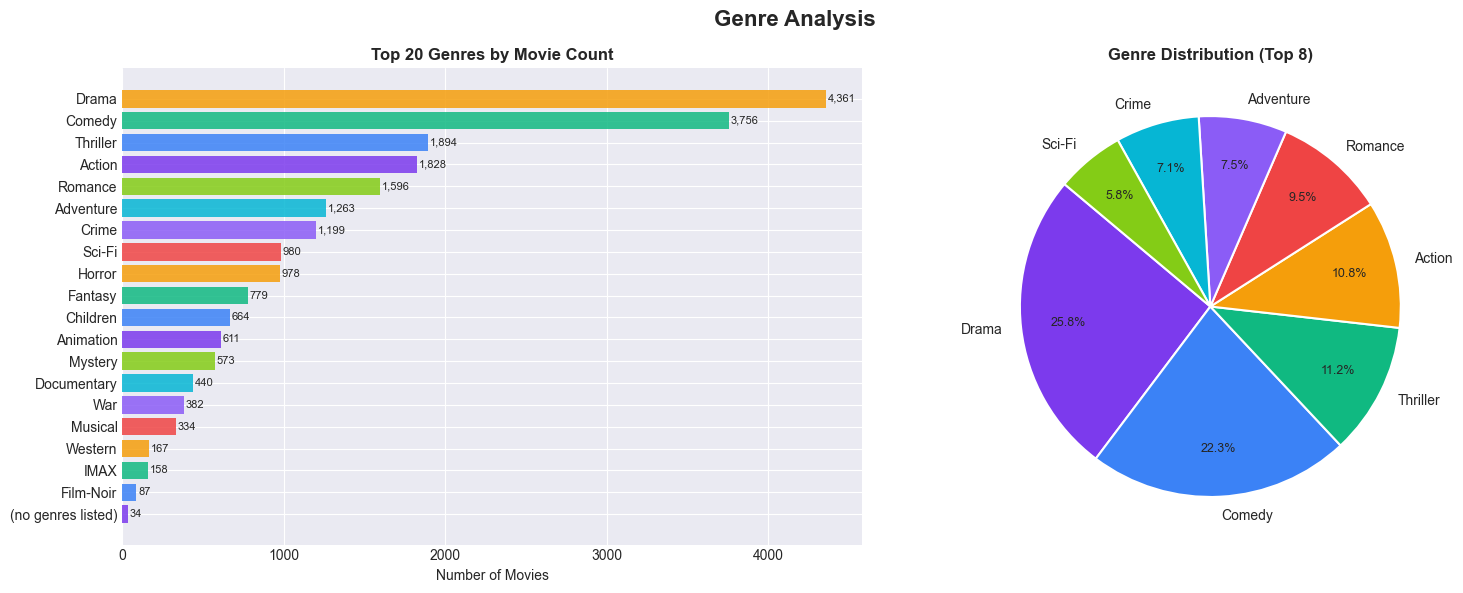

✅ Fig 2 saved


In [5]:
# Parse genres
all_genres = []
for g in movies['genres'].dropna():
    all_genres.extend(g.split('|'))
genre_series = pd.Series(all_genres)
genre_counts = genre_series.value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Genre Analysis', fontsize=16, fontweight='bold')

# Bar chart
bars = axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1],
                    color=COLORS[:len(genre_counts)]*3, alpha=0.85)
axes[0].set_title('Top 20 Genres by Movie Count', fontweight='bold')
axes[0].set_xlabel('Number of Movies')
for bar, val in zip(bars, genre_counts.values[::-1]):
    axes[0].text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# Pie chart top 8
top8 = genre_counts.head(8)
wedges, texts, autotexts = axes[1].pie(
    top8.values, labels=top8.index,
    autopct='%1.1f%%', colors=COLORS, startangle=140,
    pctdistance=0.75, wedgeprops={'edgecolor':'white','linewidth':1.5})
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Genre Distribution (Top 8)', fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/fig2_genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 2 saved')

## 👤 4. User Activity Analysis

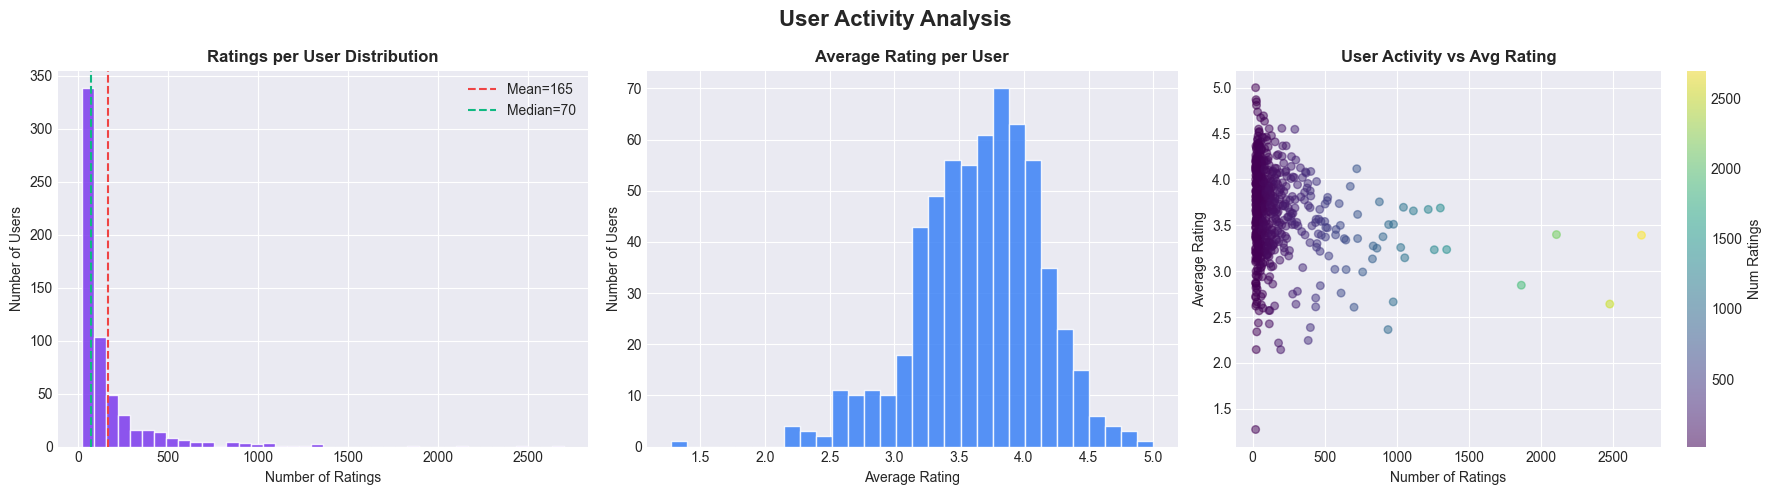

✅ Fig 3 saved
   Users with < 20 ratings (cold-start): 0
   Users with >= 20 ratings (warm):      610


In [6]:
user_activity = ratings.groupby('userId').agg(
    num_ratings=('rating','count'),
    avg_rating=('rating','mean'),
    std_rating=('rating','std')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('User Activity Analysis', fontsize=16, fontweight='bold')

# Ratings per user histogram
axes[0].hist(user_activity['num_ratings'], bins=40, color=COLORS[0], alpha=0.85, edgecolor='white')
axes[0].set_title('Ratings per User Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].axvline(user_activity['num_ratings'].mean(), color=COLORS[4],
                linestyle='--', label=f'Mean={user_activity["num_ratings"].mean():.0f}')
axes[0].axvline(user_activity['num_ratings'].median(), color=COLORS[2],
                linestyle='--', label=f'Median={user_activity["num_ratings"].median():.0f}')
axes[0].legend()

# Avg rating per user
axes[1].hist(user_activity['avg_rating'], bins=30, color=COLORS[1], alpha=0.85, edgecolor='white')
axes[1].set_title('Average Rating per User', fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Number of Users')

# Scatter: activity vs avg rating
sc = axes[2].scatter(user_activity['num_ratings'], user_activity['avg_rating'],
                     alpha=0.5, c=user_activity['num_ratings'],
                     cmap='viridis', s=30)
axes[2].set_title('User Activity vs Avg Rating', fontweight='bold')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Average Rating')
plt.colorbar(sc, ax=axes[2], label='Num Ratings')

plt.tight_layout()
plt.savefig('notebooks/fig3_user_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Fig 3 saved')
print(f'   Users with < 20 ratings (cold-start): {(user_activity["num_ratings"]<20).sum()}')
print(f'   Users with >= 20 ratings (warm):      {(user_activity["num_ratings"]>=20).sum()}')

## 🎬 5. Movie Popularity Analysis

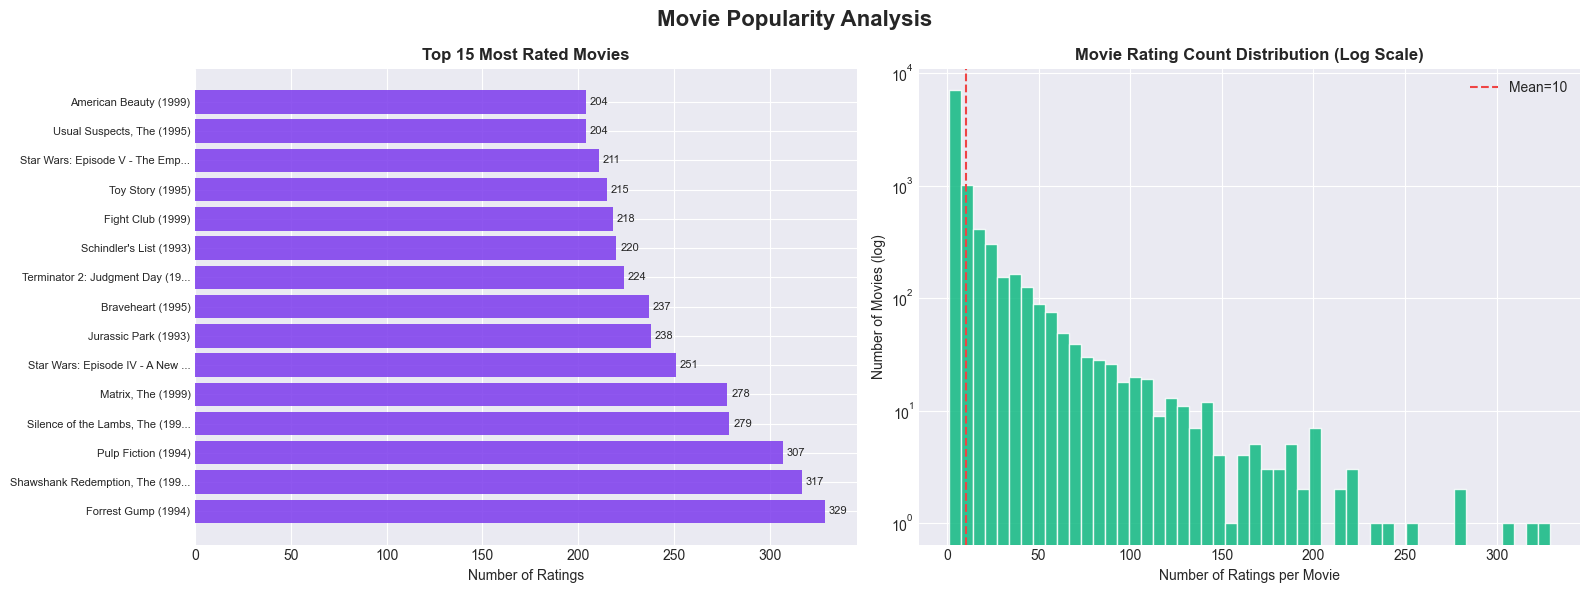

✅ Fig 4 saved


In [7]:
movie_stats = ratings.groupby('movieId').agg(
    num_ratings=('rating','count'),
    avg_rating=('rating','mean')
).reset_index()
movie_stats = movie_stats.merge(movies[['movieId','title','genres']], on='movieId')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Movie Popularity Analysis', fontsize=16, fontweight='bold')

# Top 15 most rated movies
top15 = movie_stats.nlargest(15, 'num_ratings')
short_titles = [t[:30]+'...' if len(t)>30 else t for t in top15['title']]
bars = axes[0].barh(range(len(top15)), top15['num_ratings'].values,
                    color=COLORS[0], alpha=0.85)
axes[0].set_yticks(range(len(top15)))
axes[0].set_yticklabels(short_titles, fontsize=8)
axes[0].set_title('Top 15 Most Rated Movies', fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
for bar, val in zip(bars, top15['num_ratings'].values):
    axes[0].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=8)

# Rating count distribution (log scale)
axes[1].hist(movie_stats['num_ratings'], bins=50, color=COLORS[2], alpha=0.85, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Movie Rating Count Distribution (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Number of Ratings per Movie')
axes[1].set_ylabel('Number of Movies (log)')
axes[1].axvline(movie_stats['num_ratings'].mean(), color=COLORS[4],
                linestyle='--', label=f'Mean={movie_stats["num_ratings"].mean():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/fig4_movie_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 4 saved')

## 📅 6. Rating Trends Over Time

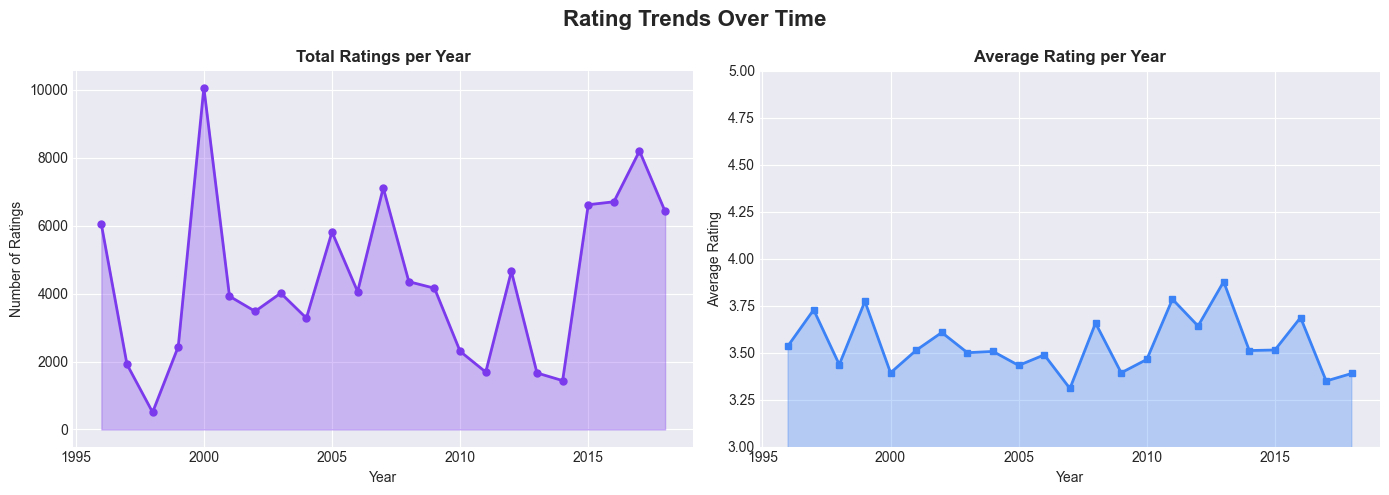

✅ Fig 5 saved


In [8]:
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year
ratings['month'] = ratings['date'].dt.month

yearly = ratings.groupby('year').agg(
    count=('rating','count'),
    avg=('rating','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Trends Over Time', fontsize=16, fontweight='bold')

# Ratings per year
axes[0].fill_between(yearly['year'], yearly['count'], alpha=0.3, color=COLORS[0])
axes[0].plot(yearly['year'], yearly['count'], color=COLORS[0], linewidth=2, marker='o', markersize=5)
axes[0].set_title('Total Ratings per Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Ratings')

# Avg rating per year
axes[1].fill_between(yearly['year'], yearly['avg'], alpha=0.3, color=COLORS[1])
axes[1].plot(yearly['year'], yearly['avg'], color=COLORS[1], linewidth=2, marker='s', markersize=5)
axes[1].set_title('Average Rating per Year', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.0, 5.0)

plt.tight_layout()
plt.savefig('notebooks/fig5_rating_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 5 saved')

## 🔥 7. User-Movie Interaction Matrix (Sparsity Visualization)

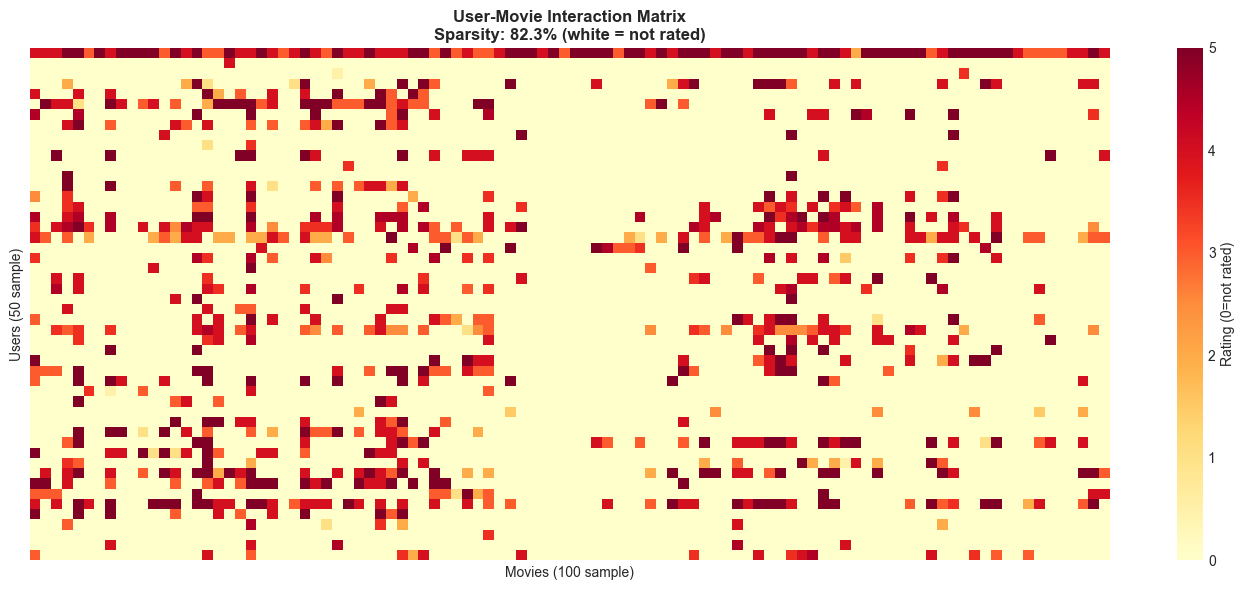

✅ Fig 6 saved | Sample sparsity: 82.3%


In [9]:
# Sample 50 users and 100 movies for visualization
sample_users  = ratings['userId'].unique()[:50]
sample_movies = ratings['movieId'].unique()[:100]

sample = ratings[
    ratings['userId'].isin(sample_users) &
    ratings['movieId'].isin(sample_movies)
]

matrix = sample.pivot_table(
    index='userId', columns='movieId', values='rating'
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(matrix, ax=ax, cmap='YlOrRd', linewidths=0,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'Rating (0=not rated)'})
ax.set_title('User-Movie Interaction Matrix (Sample: 50 Users × 100 Movies)\n'
             'White = Not Rated (Sparsity visible)', fontweight='bold')
ax.set_xlabel('Movies (100 sample)')
ax.set_ylabel('Users (50 sample)')

sparsity = (matrix == 0).sum().sum() / (matrix.shape[0]*matrix.shape[1])
ax.set_title(f'User-Movie Interaction Matrix\nSparsity: {sparsity*100:.1f}% (white = not rated)',
             fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/fig6_sparsity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Fig 6 saved | Sample sparsity: {sparsity*100:.1f}%')

## 🎯 8. Genre-Based Average Ratings

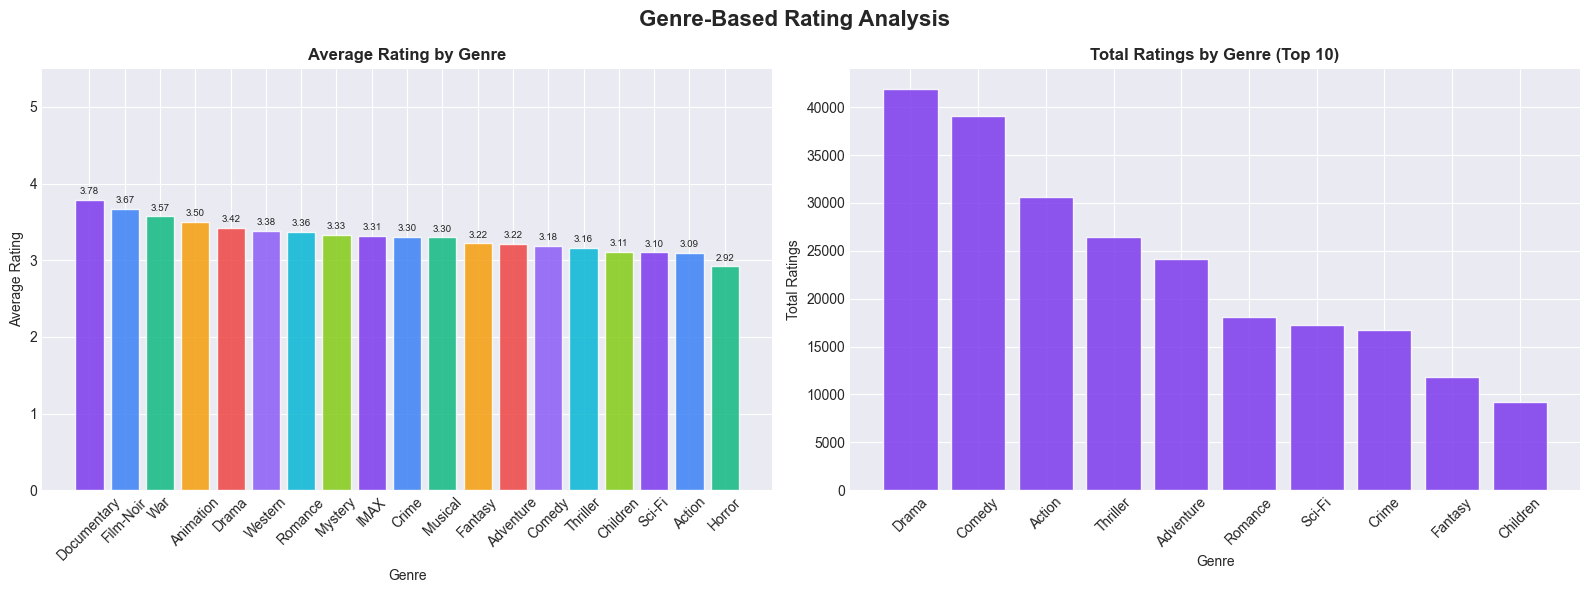

✅ Fig 7 saved


In [10]:
# Explode genres
movies_exp = movies.copy()
movies_exp['genre_list'] = movies_exp['genres'].str.split('|')
movies_exp = movies_exp.explode('genre_list')
movies_exp = movies_exp[movies_exp['genre_list'] != '(no genres listed)']

genre_ratings = movies_exp.merge(
    ratings.groupby('movieId').agg(avg=('rating','mean'),cnt=('rating','count')).reset_index(),
    on='movieId'
)
genre_avg = genre_ratings.groupby('genre_list').agg(
    avg_rating=('avg','mean'),
    total_ratings=('cnt','sum'),
    movie_count=('movieId','nunique')
).reset_index().sort_values('avg_rating', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Genre-Based Rating Analysis', fontsize=16, fontweight='bold')

# Avg rating by genre
colors_bar = [COLORS[i%len(COLORS)] for i in range(len(genre_avg))]
bars = axes[0].bar(genre_avg['genre_list'], genre_avg['avg_rating'],
                   color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].set_title('Average Rating by Genre', fontweight='bold')
axes[0].set_xlabel('Genre')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5.5)
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, genre_avg['avg_rating']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=7)

# Total ratings by genre
top_genres = genre_avg.nlargest(10, 'total_ratings')
axes[1].bar(top_genres['genre_list'], top_genres['total_ratings'],
            color=COLORS[0], alpha=0.85, edgecolor='white')
axes[1].set_title('Total Ratings by Genre (Top 10)', fontweight='bold')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Total Ratings')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('notebooks/fig7_genre_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 7 saved')

## 📊 9. Model Evaluation Results

📊 Evaluation Results:


,Precision@10,Recall@10,NDCG@10,HitRate@10,RMSE
Model,,,,,
Content-Based (TF-IDF),0.042,0.0111,0.0558,0.42,NaN
SVD (Collaborative),0.000,0.0000,0.0000,0.00,1.8384
Neural CF (NCF),0.000,0.0000,0.0000,0.00,NaN


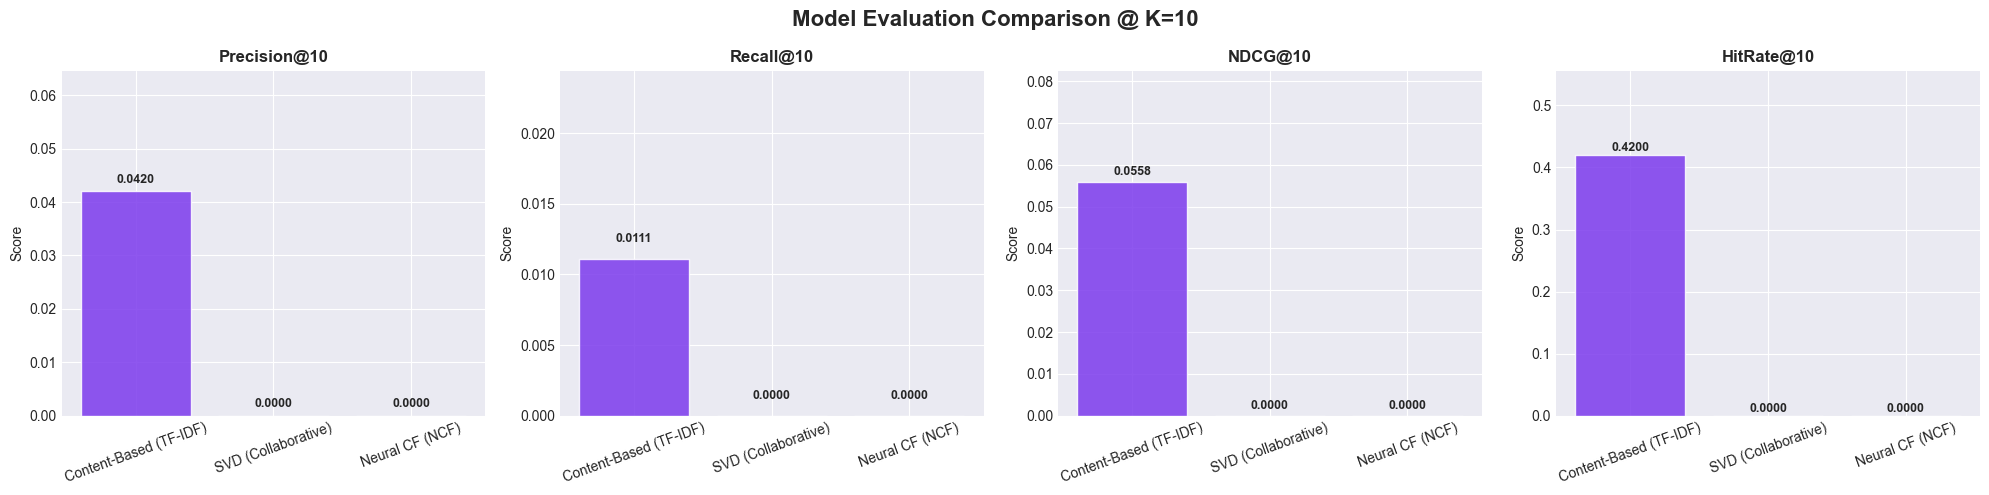

✅ Fig 8 saved


In [11]:
eval_df = pd.read_csv('models/evaluation_results.csv', index_col=0)
print('📊 Evaluation Results:')
display(eval_df)

# Replace N/A with 0 for plotting
plot_df = eval_df.copy().replace('N/A', 0)
metrics = ['Precision@10', 'Recall@10', 'NDCG@10', 'HitRate@10']
available = [m for m in metrics if m in plot_df.columns]

fig, axes = plt.subplots(1, len(available), figsize=(5*len(available), 5))
if len(available) == 1: axes = [axes]
fig.suptitle('Model Evaluation Comparison @ K=10', fontsize=16, fontweight='bold')

models_list = plot_df.index.tolist()
bar_colors  = COLORS[:len(models_list)]

for ax, metric in zip(axes, available):
    vals = plot_df[metric].astype(float).values
    bars = ax.bar(models_list, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, max(vals)*1.3+0.01)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('notebooks/fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 8 saved')

## 🗓️ 10. Movie Release Year Distribution

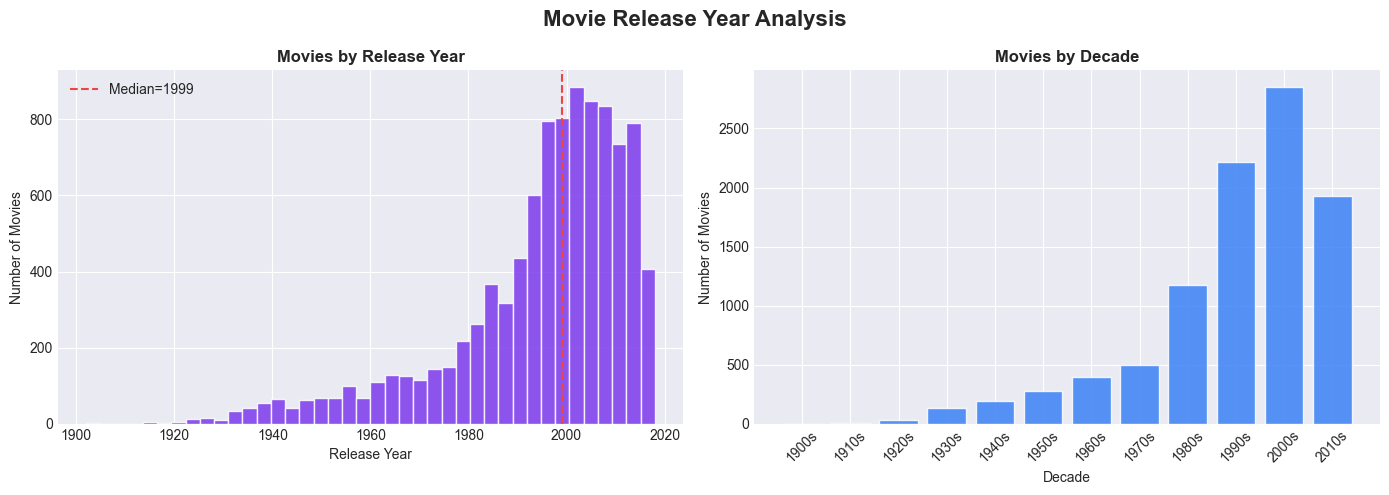

✅ Fig 9 saved


In [12]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)
movies_with_year = movies.dropna(subset=['year'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Movie Release Year Analysis', fontsize=16, fontweight='bold')

# Year distribution
axes[0].hist(movies_with_year['year'], bins=40, color=COLORS[0], alpha=0.85, edgecolor='white')
axes[0].set_title('Movies by Release Year', fontweight='bold')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(movies_with_year['year'].median(), color=COLORS[4],
                linestyle='--', label=f'Median={int(movies_with_year["year"].median())}')
axes[0].legend()

# Decade grouping
movies_with_year['decade'] = (movies_with_year['year']//10*10).astype(int)
decade_counts = movies_with_year['decade'].value_counts().sort_index()
axes[1].bar([str(d)+'s' for d in decade_counts.index], decade_counts.values,
            color=COLORS[1], alpha=0.85, edgecolor='white')
axes[1].set_title('Movies by Decade', fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Number of Movies')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('notebooks/fig9_release_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fig 9 saved')

## ✅ 11. EDA Summary

In [13]:
print('='*60)
print('  EDA SUMMARY — KEY FINDINGS')
print('='*60)
print(f'  1. Dataset has {len(ratings):,} ratings across {ratings["userId"].nunique()} users')
print(f'  2. Average rating: {ratings["rating"].mean():.2f} (positive bias observed)')
print(f'  3. Most common rating: {ratings["rating"].mode()[0]} stars')
print(f'  4. Most popular genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} movies)')
print(f'  5. Highest rated genre: {genre_avg.iloc[0]["genre_list"]} ({genre_avg.iloc[0]["avg_rating"]:.2f})')
print(f'  6. Matrix sparsity: {sparsity*100:.1f}% — justifies collaborative filtering')
cold_start = (user_activity['num_ratings']<20).sum()
print(f'  7. Cold-start users (<20 ratings): {cold_start} ({cold_start/len(user_activity)*100:.1f}%)')
print(f'  8. Top movie: {movie_stats.nlargest(1,"num_ratings").iloc[0]["title"]}')
print(f'     ({movie_stats.nlargest(1,"num_ratings").iloc[0]["num_ratings"]} ratings)')
print('='*60)
print('  All figures saved to notebooks/ folder')
print('='*60)

  EDA SUMMARY — KEY FINDINGS
  1. Dataset has 100,836 ratings across 610 users
  2. Average rating: 3.50 (positive bias observed)
  3. Most common rating: 4.0 stars
  4. Most popular genre: Drama (4,361 movies)
  5. Highest rated genre: Documentary (3.78)
  6. Matrix sparsity: 82.3% — justifies collaborative filtering
  7. Cold-start users (<20 ratings): 0 (0.0%)
  8. Top movie: Forrest Gump (1994)
     (329 ratings)
  All figures saved to notebooks/ folder
